In [1]:
%cd ..
from app.conf.run import build_interpretability_run_config
from app.modeling import build_model
from app.data_providers import ready_split_dataset
from plot.interpretability import feature_importance_bar_plot, ShapPlotter, create_shap_plotter_from_model_and_data
from evaluation.shap import shap_explainer, shap_values
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [2]:
config = build_interpretability_run_config()
model = build_model(config.model_config)

X_train, y_train, X_test, y_test, X_train_orig, X_test_orig = ready_split_dataset(config)
model.fit(X_train,y_train)
shap_plotter = create_shap_plotter_from_model_and_data(model, X_test, X_train)

Repo card metadata block was not found. Setting CardData to empty.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 151235, number of negative: 162044
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 650
[LightGBM] [Info] Number of data points in the train set: 313279, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.482749 -> initscore=-0.069033
[LightGBM] [Info] Start training from score -0.069033


/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


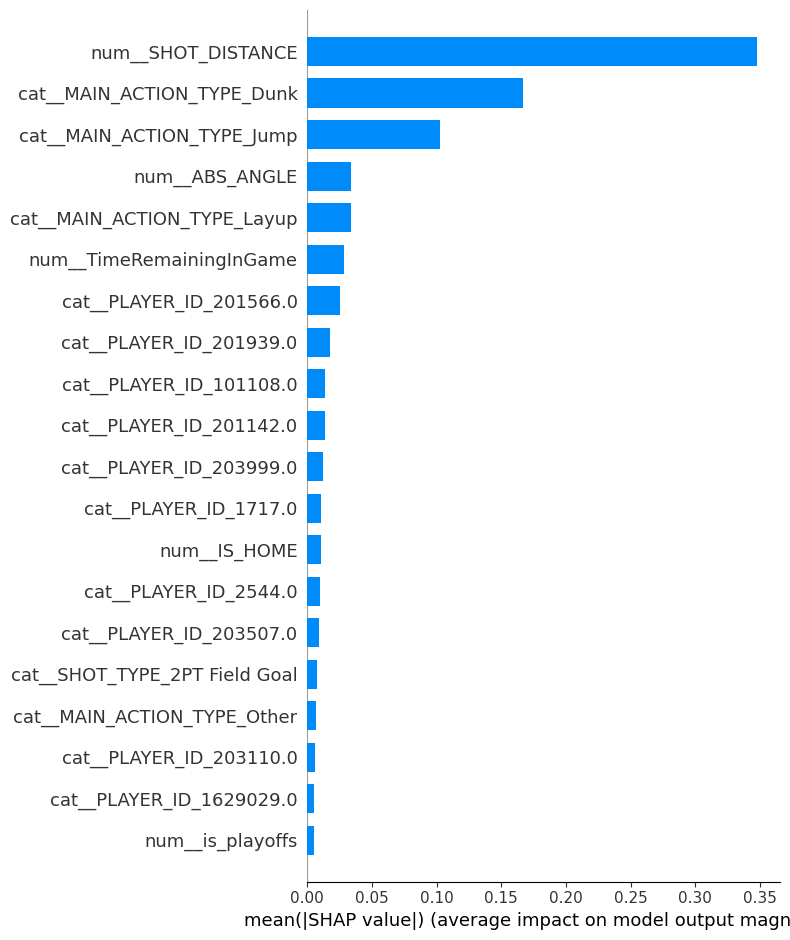

In [3]:
shap_plotter.plot_summary()

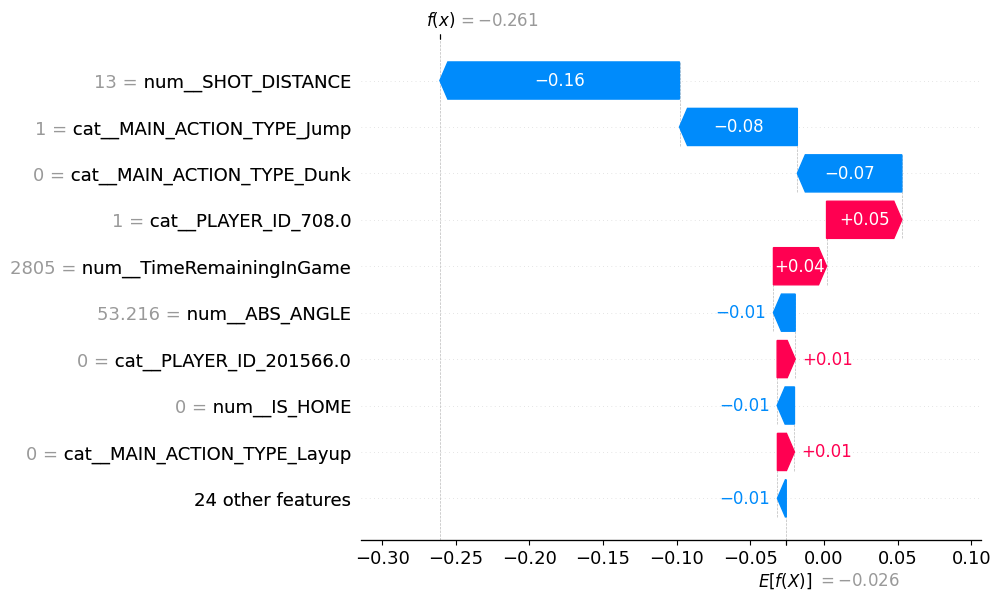

In [4]:
import matplotlib.pyplot as plt
shap_plotter.plot_waterfall(3)
plt.show()

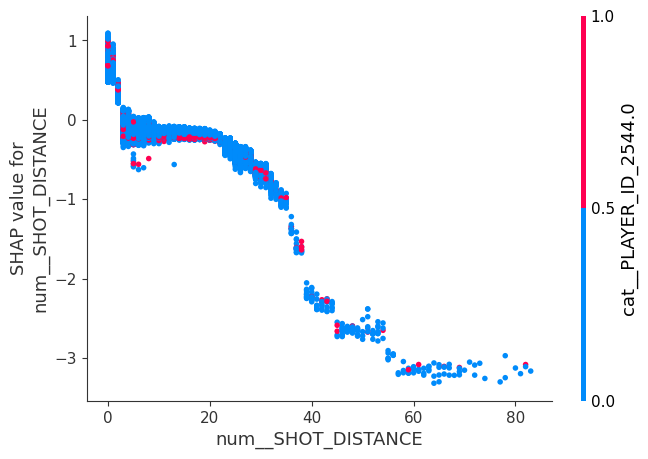

In [5]:
import shap
shap.dependence_plot(
            "num__SHOT_DISTANCE",
            shap_plotter.shap_values,
            X_test
        )

<Figure size 3500x3500 with 0 Axes>

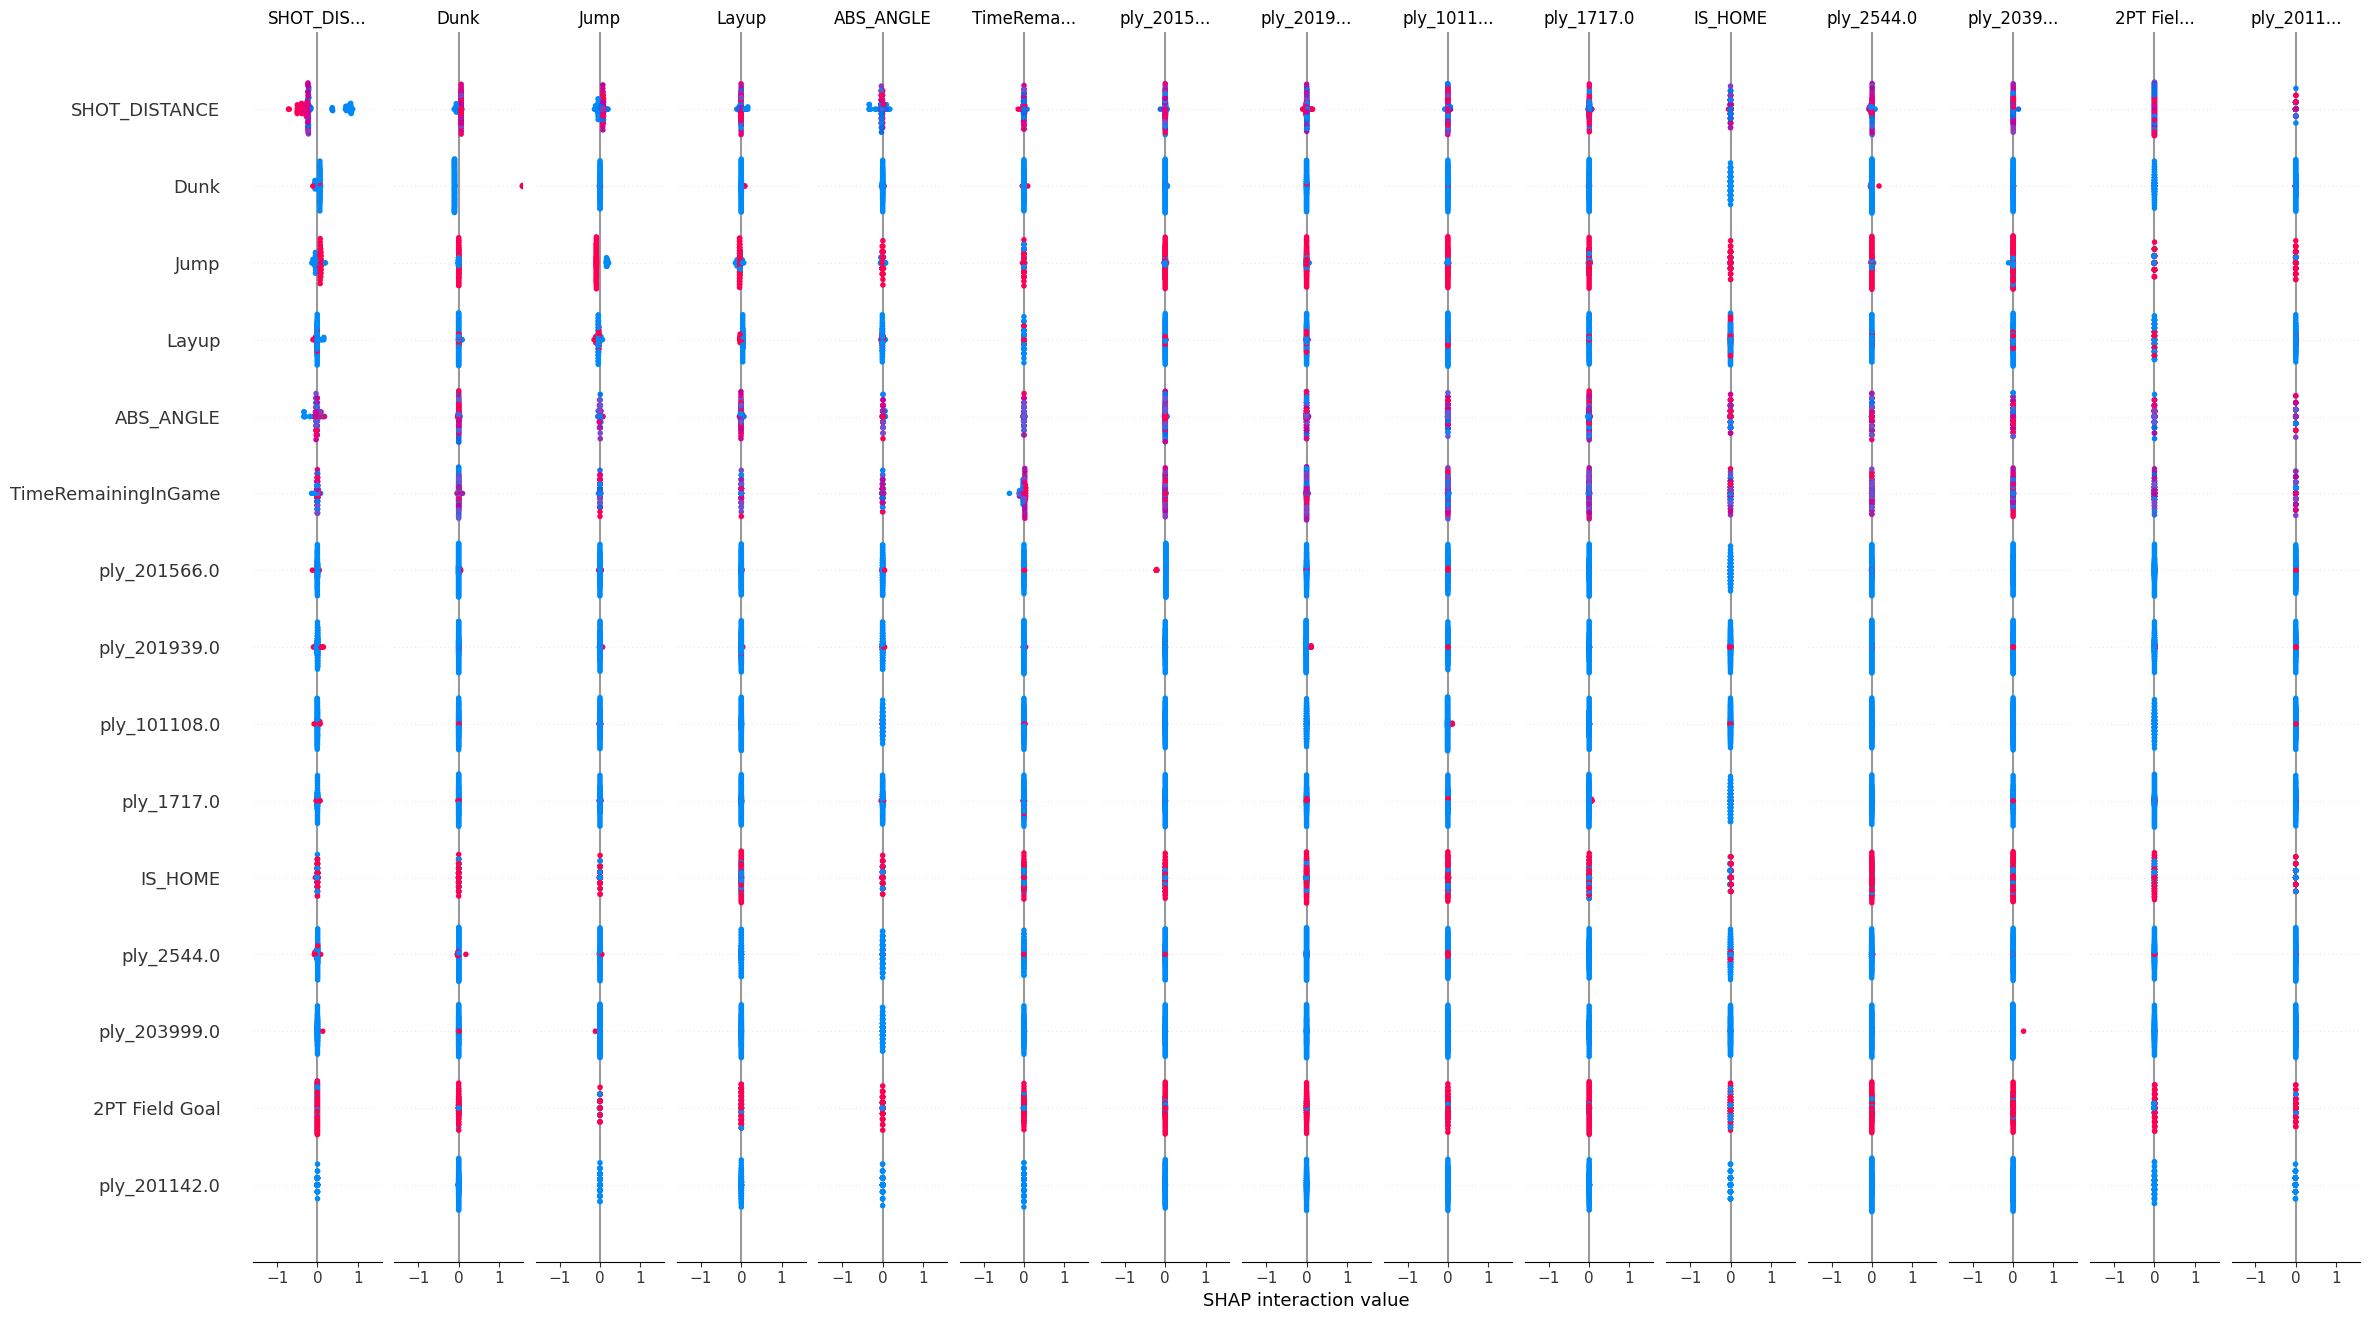

In [21]:
plt.figure(figsize=(35,35))
#shap_plotter.plot_interaction_summary()
sample = shap_plotter.X_test.sample(100, random_state=42)

sample_renamed = sample.copy()

sample_renamed.columns = [
    c.replace("cat__", "").replace("MAIN_ACTION_TYPE_", "").replace("SHOT_TYPE_", "").replace("num__", "").replace("PLAYER_ID", "ply")
    for c in sample.columns
]
interaction_values = shap_plotter.explainer.shap_interaction_values(sample_renamed)
shap.summary_plot(
    interaction_values,
    sample_renamed,
    max_display=15,
    plot_size=(350, 350)
)



In [23]:
import numpy as np
import pandas as pd
interaction_values = shap_plotter.explainer.shap_interaction_values(sample)
interaction_strength = np.abs(interaction_values).mean(axis=0)
# 
interaction_df = pd.DataFrame(
    interaction_strength,
    columns=X_test.columns,
    index=X_test.columns
)



In [29]:
pairs = []
# Calculating most important interacting column pairs
for i in range(len(X_test.columns)):
    for j in range(i+1, len(X_test.columns)):

        strength = np.abs(
            interaction_values[:, i, j]
        ).mean()

        pairs.append((
            X_test.columns[i],
            X_test.columns[j],
            strength
        ))

pairs = sorted(
    pairs,
    key=lambda x: x[2],
    reverse=True
)

# pairs[:10]

cat__MAIN_ACTION_TYPE_Jump


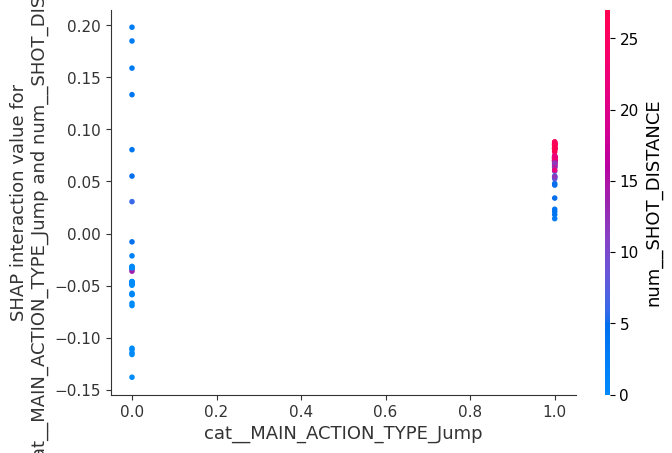

cat__MAIN_ACTION_TYPE_Dunk


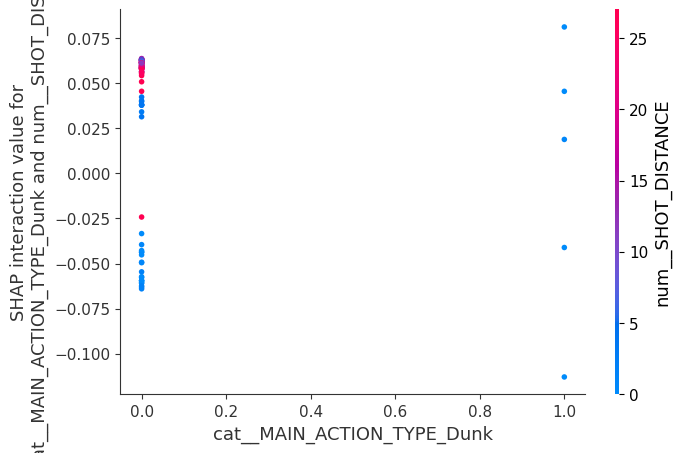

num__SHOT_DISTANCE


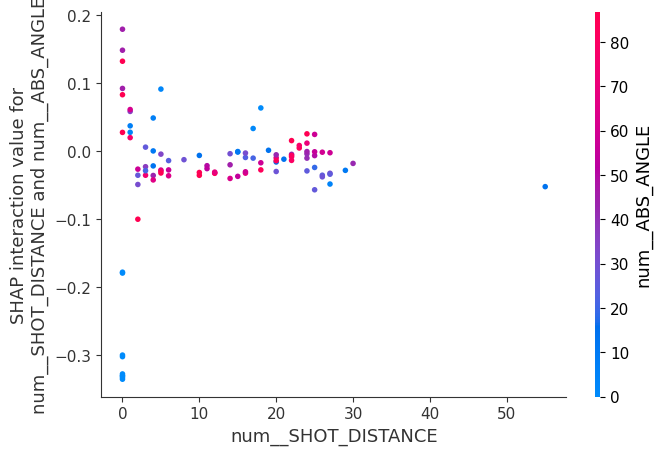

cat__MAIN_ACTION_TYPE_Jump


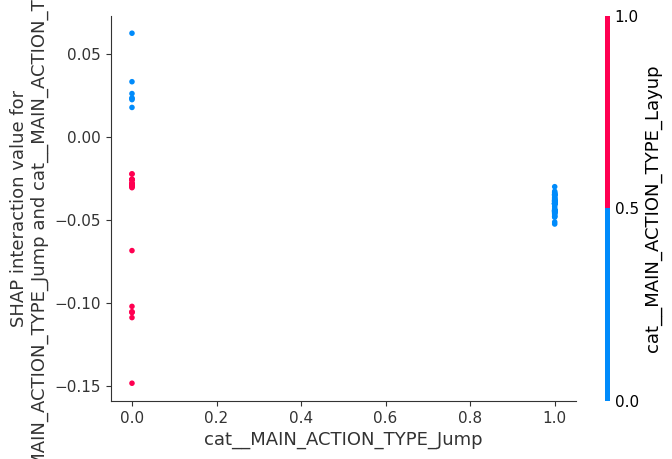

cat__MAIN_ACTION_TYPE_Layup


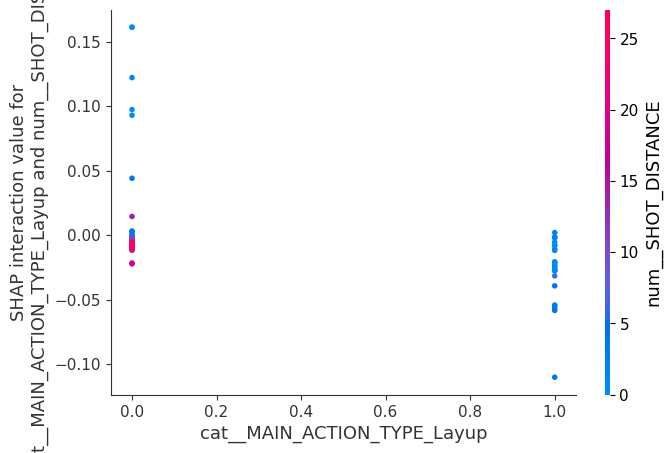

cat__MAIN_ACTION_TYPE_Jump


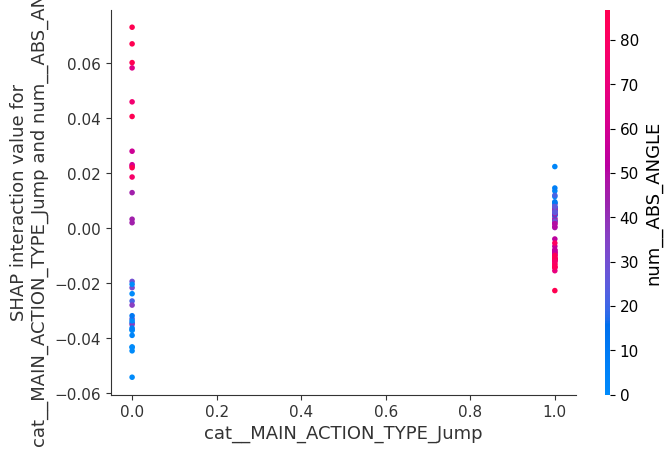

cat__PLAYER_ID_201939.0


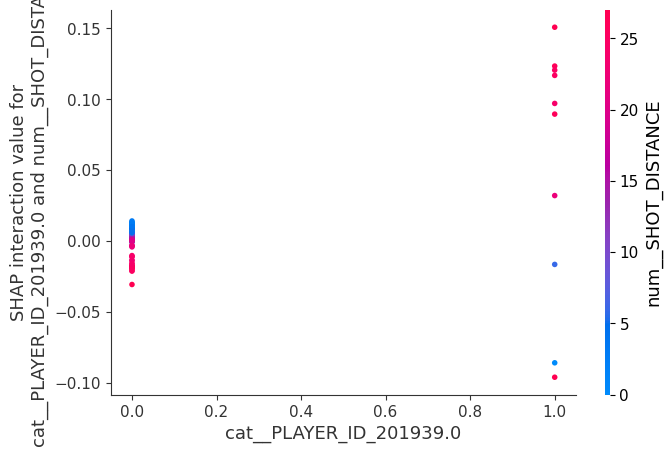

cat__PLAYER_ID_2544.0


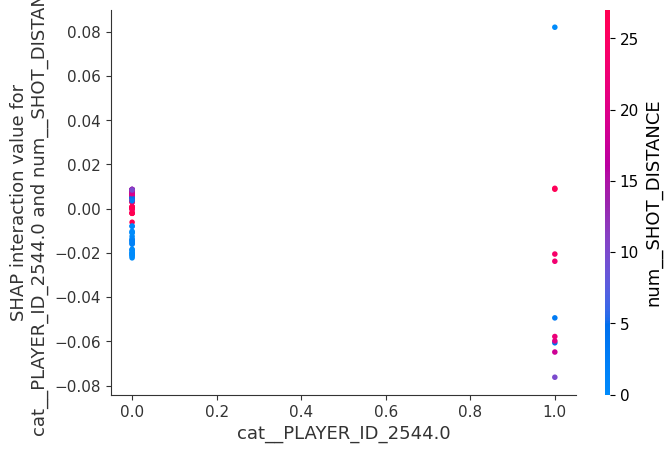

cat__PLAYER_ID_203507.0


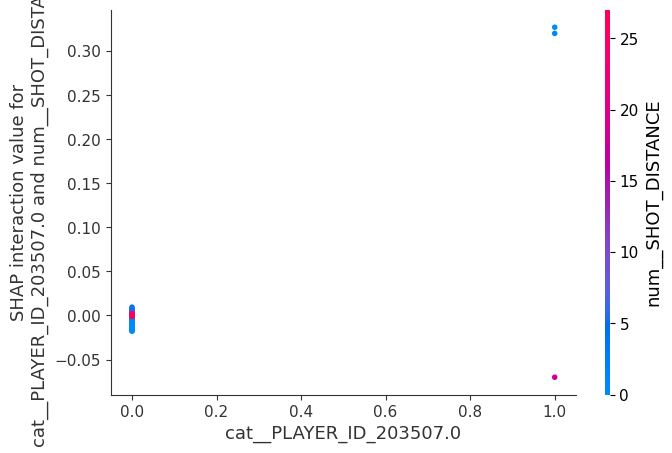

num__SHOT_DISTANCE


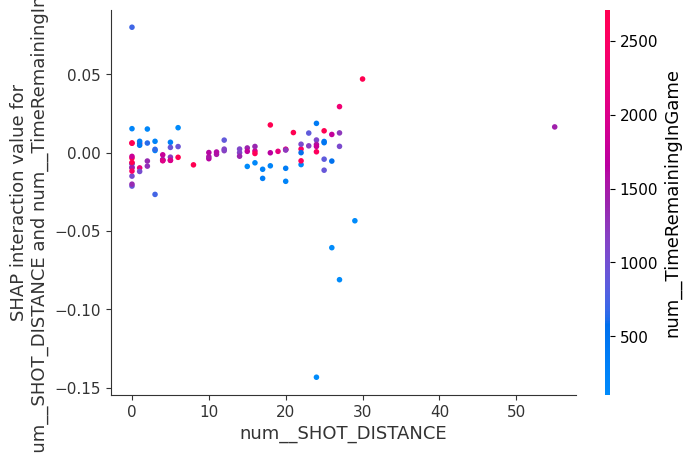

In [28]:
# dependence plot for most important features interactions
for pair in pairs[:10]:
    print(pair[0])
    shap.dependence_plot(
    (pair[0],pair[1]),
    interaction_values,
    sample
)